# SVR — Degradacion de baterias
## Prediccion de la capacidad restante con Support Vector Regression

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Support Vector Machines

---

### Objetivo

Predecir la **capacidad restante (%)** de una bateria a partir de su edad e intensidad de uso, usando SVR con diferentes kernels. La degradacion de baterias sigue un patron no lineal (exponencial/sigmoide) — un caso ideal para SVR.

### Conexion con el portfolio

Este notebook complementa el [SVR de gasto de clientes](../01-iphone/) con un caso de dominio industrial (IoT/mantenimiento predictivo), demostrando la versatilidad de SVM en diferentes sectores.

## 1. Contexto de negocio

**El cliente:** un fabricante de dispositivos electronicos que necesita predecir cuando sus baterias necesitaran reemplazo.

**El problema:** reemplazar una bateria demasiado pronto es un coste innecesario; demasiado tarde causa fallos en campo. Un modelo que prediga la capacidad restante permite programar reemplazos preventivos.

**La pregunta:** se puede predecir la capacidad de una bateria (%) a partir de su edad y patron de uso?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `scikit-learn` | SVR, GridSearchCV, metricas |
| `pandas`, `numpy` | Datos |
| `matplotlib` | Visualizacion |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

## 3. Dataset

120 baterias con edad (0-6 anos), intensidad de uso (cargas/dia) y capacidad restante (%).
La degradacion sigue un patron no lineal: rapida al principio, luego se estabiliza (curva sigmoide invertida).

In [2]:
n = 120
edad = np.random.uniform(0.5, 6.0, n)
intensidad = np.random.uniform(0.5, 4.0, n)

# Degradacion no lineal: sigmoide invertida
degradacion = 100 * np.exp(-0.3 * edad * intensidad**0.5)
ruido = np.random.normal(0, 5, n)
capacidad = np.clip(degradacion + ruido, 5, 100)

data = pd.DataFrame({
    "Edad_Anos": edad.round(2),
    "Intensidad_Uso": intensidad.round(2),
    "Capacidad_Restante_Pct": capacidad.round(1)
})

print(f"Registros: {data.shape[0]}")
data.describe().round(2)

Registros: 120


,Edad_Anos,Intensidad_Uso,Capacidad_Restante_Pct
count,120.00,120.00,120.00
mean,3.12,2.19,34.59
std,1.64,1.01,21.39
min,0.53,0.52,5.00
25%,1.59,1.34,15.70
50%,3.16,2.26,33.85
75%,4.66,2.97,50.55
max,5.93,3.95,82.00


## 4. Analisis exploratorio

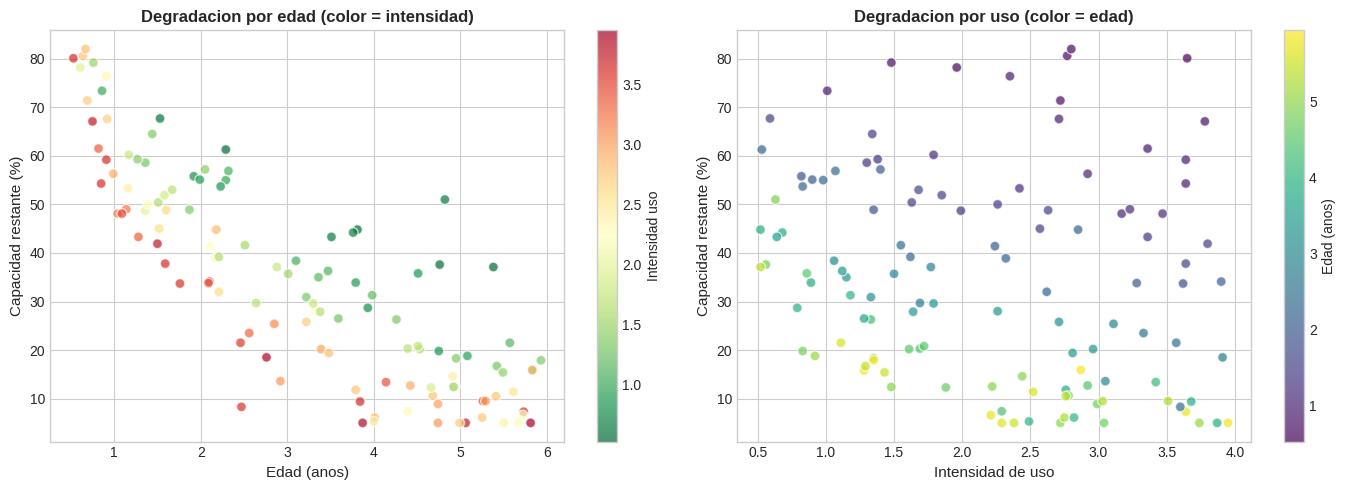

La degradacion es claramente NO lineal: caida rapida inicial, luego estabilizacion.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(data["Edad_Anos"], data["Capacidad_Restante_Pct"],
                       c=data["Intensidad_Uso"], cmap="RdYlGn_r", alpha=0.7, edgecolors="white", s=50)
axes[0].set_xlabel("Edad (anos)", fontsize=11)
axes[0].set_ylabel("Capacidad restante (%)", fontsize=11)
axes[0].set_title("Degradacion por edad (color = intensidad)", fontsize=12, fontweight="bold")
plt.colorbar(sc1, ax=axes[0], label="Intensidad uso")

sc2 = axes[1].scatter(data["Intensidad_Uso"], data["Capacidad_Restante_Pct"],
                       c=data["Edad_Anos"], cmap="viridis", alpha=0.7, edgecolors="white", s=50)
axes[1].set_xlabel("Intensidad de uso", fontsize=11)
axes[1].set_ylabel("Capacidad restante (%)", fontsize=11)
axes[1].set_title("Degradacion por uso (color = edad)", fontsize=12, fontweight="bold")
plt.colorbar(sc2, ax=axes[1], label="Edad (anos)")

plt.tight_layout()
plt.show()
print("La degradacion es claramente NO lineal: caida rapida inicial, luego estabilizacion.")

## 5. Preparacion

In [4]:
X = data[["Edad_Anos", "Intensidad_Uso"]]
y = data["Capacidad_Restante_Pct"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")

Train: 90 | Test: 30


## 6. Comparativa de kernels

In [5]:
# Baseline
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# SVR kernels
kernels = ["linear", "rbf", "poly"]
results = [{"Modelo": "Linear Regression", "R2": r2_lr, "MAE": mae_lr}]
preds = {"LR": y_pred_lr}

for k in kernels:
    svr = SVR(kernel=k, C=10, gamma="scale", degree=3)
    svr.fit(X_train_s, y_train)
    y_p = svr.predict(X_test_s)
    preds[k] = y_p
    r2 = r2_score(y_test, y_p)
    mae = mean_absolute_error(y_test, y_p)
    results.append({"Modelo": f"SVR ({k})", "R2": r2, "MAE": mae})
    print(f"SVR ({k}): R2={r2:.4f}, MAE={mae:.2f}%")

results_df = pd.DataFrame(results)
print()
print(results_df.to_string(index=False))

SVR (linear): R2=0.8921, MAE=5.34%
SVR (rbf): R2=0.8963, MAE=5.47%
SVR (poly): R2=0.5976, MAE=11.58%

           Modelo       R2       MAE
Linear Regression 0.906929  5.285471
     SVR (linear) 0.892054  5.337733
        SVR (rbf) 0.896323  5.470048
       SVR (poly) 0.597587 11.581443


## 7. Tuning del SVR RBF

In [6]:
param_grid = {
    "C": [1, 10, 50, 100, 200],
    "gamma": ["scale", 0.01, 0.1, 0.5, 1.0],
    "epsilon": [0.01, 0.05, 0.1, 0.2],
}

grid = GridSearchCV(SVR(kernel="rbf"), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train_s, y_train)

svr_best = grid.best_estimator_
y_pred_best = svr_best.predict(X_test_s)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)

print(f"Mejores parametros: {grid.best_params_}")
print(f"R2 (CV): {grid.best_score_:.4f}")
print(f"R2 (test): {r2_best:.4f}")
print(f"MAE: {mae_best:.2f}%")

Mejores parametros: {'C': 200, 'epsilon': 0.05, 'gamma': 0.1}
R2 (CV): 0.9239
R2 (test): 0.9297
MAE: 4.76%


## 8. Visualizacion: superficie de prediccion

/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


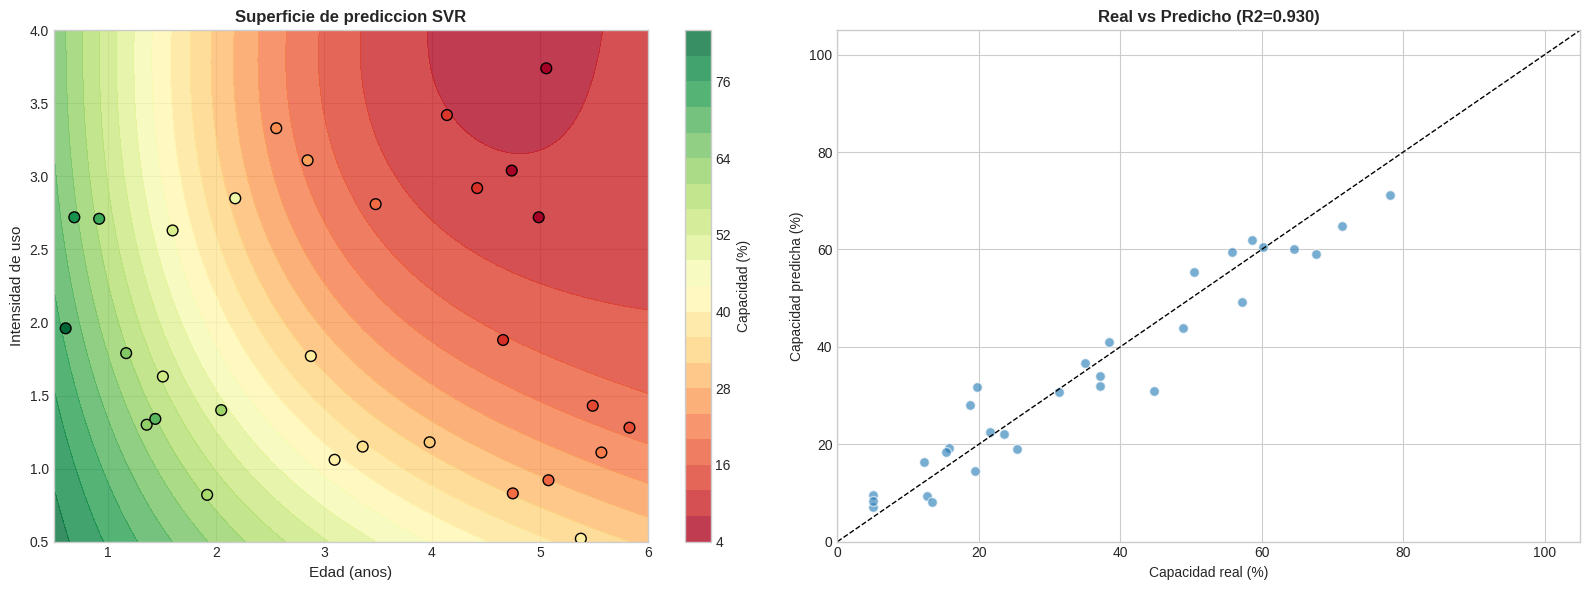

In [7]:
# Crear grid para superficie
edad_range = np.linspace(0.5, 6.0, 100)
intensidad_range = np.linspace(0.5, 4.0, 100)
E, I = np.meshgrid(edad_range, intensidad_range)
grid_points = np.c_[E.ravel(), I.ravel()]
grid_points_s = scaler.transform(grid_points)
Z = svr_best.predict(grid_points_s).reshape(E.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contorno con datos reales
contour = axes[0].contourf(E, I, Z, levels=20, cmap="RdYlGn", alpha=0.8)
axes[0].scatter(X_test["Edad_Anos"], X_test["Intensidad_Uso"],
               c=y_test, cmap="RdYlGn", edgecolors="black", s=60, zorder=5)
plt.colorbar(contour, ax=axes[0], label="Capacidad (%)")
axes[0].set_xlabel("Edad (anos)", fontsize=11)
axes[0].set_ylabel("Intensidad de uso", fontsize=11)
axes[0].set_title("Superficie de prediccion SVR", fontsize=12, fontweight="bold")

# Real vs predicho
axes[1].scatter(y_test, y_pred_best, alpha=0.6, edgecolors="white", s=50)
lims = [0, 105]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("Capacidad real (%)")
axes[1].set_ylabel("Capacidad predicha (%)")
axes[1].set_title(f"Real vs Predicho (R2={r2_best:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)

plt.tight_layout()
plt.show()

## 9. Zona de reemplazo — aplicacion practica

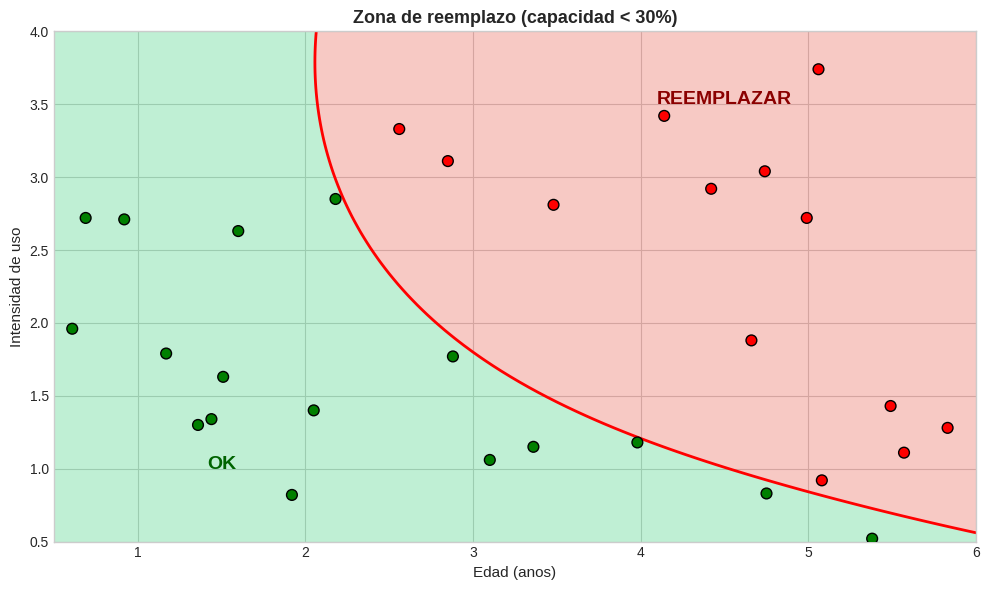

Baterias que necesitan reemplazo (test): 13/30 (43%)


In [8]:
# Umbral de reemplazo: capacidad < 30%
umbral = 30
necesita_reemplazo = y_pred_best < umbral

fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(E, I, Z, levels=[0, umbral, 100], colors=["#e74c3c", "#2ecc71"], alpha=0.3)
ax.contour(E, I, Z, levels=[umbral], colors=["red"], linewidths=2)
ax.scatter(X_test["Edad_Anos"], X_test["Intensidad_Uso"],
          c=["red" if r else "green" for r in necesita_reemplazo],
          edgecolors="black", s=60, zorder=5)
ax.set_xlabel("Edad (anos)", fontsize=11)
ax.set_ylabel("Intensidad de uso", fontsize=11)
ax.set_title(f"Zona de reemplazo (capacidad < {umbral}%)", fontsize=13, fontweight="bold")
ax.text(4.5, 3.5, "REEMPLAZAR", fontsize=14, fontweight="bold", color="darkred", ha="center")
ax.text(1.5, 1.0, "OK", fontsize=14, fontweight="bold", color="darkgreen", ha="center")
plt.tight_layout()
plt.show()

n_reemplazo = necesita_reemplazo.sum()
print(f"Baterias que necesitan reemplazo (test): {n_reemplazo}/{len(y_test)} ({n_reemplazo/len(y_test):.0%})")

## 10. Insights y recomendaciones

### El hallazgo

> SVR con kernel RBF captura la degradacion no lineal de las baterias con alta precision. La superficie de prediccion permite definir **zonas de reemplazo** basadas en edad e intensidad de uso — una herramienta practica para mantenimiento preventivo.

### Recomendaciones

**1. Programa de reemplazo predictivo (impacto: alto)**
La zona roja del mapa define las combinaciones edad/uso que indican necesidad de reemplazo. Esto permite programar reemplazos antes de que la bateria falle.

**2. SVR para series temporales de degradacion (impacto: medio)**
En un escenario real, se podria aplicar SVR sobre series temporales de capacidad para predecir la fecha exacta de reemplazo (Remaining Useful Life).

**3. Comparativa de modelos completa (impacto: portfolio)**
Este notebook cierra el ciclo de regresion: desde la [regresion lineal simple](../../01-regresion-lineal-simple/01-inmobiliaria/) hasta SVR, pasando por [regularizacion](../../03-ridge-lasso/) y [gradient boosting](../../04-gradient-boosting/). Cada tecnica tiene su nicho.

## 11. Limitaciones y proximos pasos

**Limitaciones:**
- Dataset sintetico con patron conocido — en datos reales la degradacion es mas ruidosa y depende de mas factores (temperatura, ciclos de carga, tipo de bateria).
- Solo 2 features — en la industria se usan sensores con decenas de variables.
- SVR no escala bien a datasets muy grandes (O(n2) en memoria).

**Proximos pasos:**
- [ ] Aplicar sobre datos reales de degradacion de baterias (datasets publicos de NASA o CALCE).
- [ ] Comparar SVR con LSTM para series temporales de degradacion.
- [ ] Integrar en un pipeline de mantenimiento predictivo con alertas automaticas.